# Custom Figure Generator for Papers
- Load multiple runtime instances and compare plots.
- Assuming usage of similar spectral configuration (same specConfigName)
- 

In [5]:
import glob
import os
from codec import CodecSystem, readPhotometry
# codec.py contains the CodecSystem class

import numpy as np
import matplotlib.pyplot as plt
import pickle

# make plotPaths in top directory
topDir = os.path.dirname(os.getcwd())
plotDir = os.path.join(topDir, 'paperPlots')
if not os.path.exists(plotDir):
    os.makedirs(plotDir)
print("Saving plots to ", plotDir)

test = True
# test = False

Saving plots to  /Users/nguyendat/Documents/GitHub/polarVortexJwst/paperPlots


### Helpers function

In [6]:
### Functions to read in spectra time series data ###
default_specConfigName = '1200k_clouds=20'
def read_spec_codecs(photrunName, specConfigName=default_specConfigName):

    ### 1. Read in photometry results
    phot = readPhotometry(os.path.join(photometryh5dir, photrunName_ts))

    ### 2. Read in spectra time series data + codec data
    runname = f'timeseries_{photrunName[:-3]}_{specConfigName}'
    dirPath = os.path.join(os.getcwd(), runname)

    # Search for files matching the pattern 'i=*.h5' in the directory
    spectra_files = sorted(glob.glob(os.path.join(dirPath, 'composite*.h5')))
    codec_files = sorted(glob.glob(os.path.join(dirPath, 'codec*.h5')))

    # Initialize the specs dictionary
    specs = {}
    codecs = {}

    # Iterate through each inclination file and load spectra
    for index, file in enumerate(spectra_files):
        inclin = os.path.basename(file).split('=')[1].split('.')[0]  # Extract 'i' value from the filename

        specs[inclin] = CodecSystem.load_spectra_ts_h5(file)
        codecs[inclin] = CodecSystem.load_codec_images_h5(codec_files[index])

    ### 3. Load codec configuration
    configPath = glob.glob(os.path.join(dirPath, 'codec_config.json'))[0]
    codec_loaded = CodecSystem()
    codec_loaded.import_mapping(configPath, validate_files=False)
    
    return phot, specs, codecs, codec_loaded

### Load in PICASO spectra: n=20 runs

- All photometry runs in this notebook should use the same PICASO spectra config n=20 (hence same fsed, wavelength region, cloud setup, etc. everything spectral related).

In [7]:

### Load the full picaso result summary

# Search for .csv files in the specified directory
dir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/'
# specFolderName = 'bd_grid_20251108_162457_all5condensates'
# specFolderName = 'bd_grid_20251202_simple3clouds'
specFolderName = 'bd_grid_noCH4_20251209_153457'

specpath = os.path.join(dir, specFolderName)
specSummary = pickle.load(open(os.path.join(specpath, 'results_summary.pkl'), 'rb'))

modelID_list = [picasomodelfile['model_id'] for picasomodelfile in specSummary]
print(f"\nFound {len(modelID_list)} model IDs in the summary:")
print(modelID_list)
print("\nSample params file: ")
print(specSummary[0]['params'])

# fsed_list
fsed_list = []
# Loop through all codec_id and get fsed
for picasomodelfile in specSummary:
    fsed = picasomodelfile['params'].get('fsed', None)
    modelid = picasomodelfile['model_id']
    fsed_list.append((modelid, fsed))


Found 20 model IDs in the summary:
['bd_1200_10000_1.0E+07_1.00_cloudy', 'bd_1200_10000_1.0E+07_1.01_cloudy', 'bd_1200_10000_1.0E+07_1.02_cloudy', 'bd_1200_10000_1.0E+07_1.03_cloudy', 'bd_1200_10000_1.0E+07_1.04_cloudy', 'bd_1200_10000_1.0E+07_1.05_cloudy', 'bd_1200_10000_1.0E+07_1.06_cloudy', 'bd_1200_10000_1.0E+07_1.07_cloudy', 'bd_1200_10000_1.0E+07_1.08_cloudy', 'bd_1200_10000_1.0E+07_1.09_cloudy', 'bd_1200_10000_1.0E+07_1.10_cloudy', 'bd_1200_10000_1.0E+07_1.11_cloudy', 'bd_1200_10000_1.0E+07_1.12_cloudy', 'bd_1200_10000_1.0E+07_1.13_cloudy', 'bd_1200_10000_1.0E+07_1.14_cloudy', 'bd_1200_10000_1.0E+07_1.15_cloudy', 'bd_1200_10000_1.0E+07_1.16_cloudy', 'bd_1200_10000_1.0E+07_1.17_cloudy', 'bd_1200_10000_1.0E+07_1.18_cloudy', 'bd_1200_10000_1.0E+07_1.19_cloudy']

Sample params file: 
{'Teff': 1200, 'C_to_O': 0.0, 'mh': 1.0, 'gravity': 10000, 'kzz': 10000000.0, 'phase': 0, 'wave_range': [1, 6], 'eq': False, 'excluded_mol': 'CH4', 'mmw': 2.2, 'fsed': 1.0, 'R': 700, 'gases': ['Fe', 'M

In [8]:

### Read the photometry file
photometryh5dir = '/Users/nguyendat/Documents/GitHub/polarVortexJwst/rendering/atm_renderer/output/'

### Test-dataset: 

# 60 hours baseline, static pole: Test Static (ts)
photrunName_ts = 'test_polar_v0_static.h5'
phot_ts, specs_ts, codecs_ts, codec_loaded_ts = read_spec_codecs(photrunName_ts) 
time_ts = phot_ts['0']['time_array'] # load the time indices 

# 60 hours baseline, dynamic pole: Test Dynamic (td)
photrunName_td = 'test_polar_v0_dynamic.h5'
phot_td, specs_td, codecs_td, codec_loaded_td = read_spec_codecs(photrunName_td) 
time_td = phot_td['0']['time_array'] # load the time indices 

### JWST-data: 

# multiepoch, static pole: JWST Static (js)
photrunName_js = 'jwst_v0_static.h5'
phot_js, specs_js, codecs_js, codec_loaded_js = read_spec_codecs(photrunName_js)
time_js = phot_js['0']['time_array'] # load the time indices


Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_polar_v0_static_1200k_clouds=20/codec_config.json
  Codec combinations: 20
  Spectra assignments: 20
Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timeseries_test_polar_v0_dynamic_1200k_clouds=20/codec_config.json
  Codec combinations: 20
  Spectra assignments: 20
Added codec 'cloud_thickness' with 20 values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Generated 20 codec combinations
ID range: 0-19
Loaded codec mapping from /Users/nguyendat/Documents/GitHub/polarVortexJwst/spec_module/timese

In [9]:
### Somes helpful metadata
# codec length
n = len(codec_loaded_ts.spectra_assignments.keys())

# how to load a spectrum
if test:
    wave, flux = codec_loaded_ts.load_spectrum(codec_id=0)
    print('### Spectral assignment keys ###: \n', codec_loaded_ts.spectra_assignments.keys())
    print('### Range of wavelength values ###: \n', wave[::50])
    print('### Corresponding flux ###: \n', flux[::50])


### Spectral assignment keys ###: 
 dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19])
### Range of wavelength values ###: 
 [0.99957438 1.07358431 1.15307404 1.23844931 1.33014588 1.42863181
 1.53440977 1.64801968 1.77004144 1.90109786 2.04185789 2.19304
 2.35541585 2.52981424 2.71712533 2.91830522 3.13438075 3.36645482
 3.615712   3.88342454 4.1709589  4.47978271 4.81147229 5.16772065
 5.55034615 5.96130179]
### Corresponding flux ###: 
 [2.45420234e-09 4.41506495e-09 6.82549022e-09 1.23148160e-08
 1.89032672e-08 1.73741067e-08 4.20557653e-08 5.93475747e-08
 7.22594861e-08 8.30731523e-08 1.26519555e-07 1.60537524e-07
 1.92009615e-07 1.51329476e-07 1.50701667e-07 2.40656328e-07
 3.19187019e-07 3.50685914e-07 3.76756954e-07 3.81990088e-07
 4.33680206e-07 4.61880014e-07 4.49066258e-07 4.46483576e-07
 2.70172383e-07 4.42915717e-07]


### [Figure] Spectral-codec image + all Picaso spectra

{'0': 0.0031733268239449767, '1': 0.008026650201743176, '2': 0.0058584495211291875, '3': 0.005327168559654236, '4': 0.005700501127177175, '5': 0.006073833694700113, '6': 0.006662550435793978, '7': 0.006949729333888546, '8': 0.007524087130077682, '9': 0.008974340565455251, '10': 0.7153195583188547, '11': 0.12598538259408698, '12': 0.00852921327340867, '13': 0.008543572218313398, '14': 0.00871587955717014, '15': 0.009046135289978892, '16': 0.0119322832158293, '17': 0.01157330959321109, '18': 0.01283689674482719, '19': 0.02324713180075528}


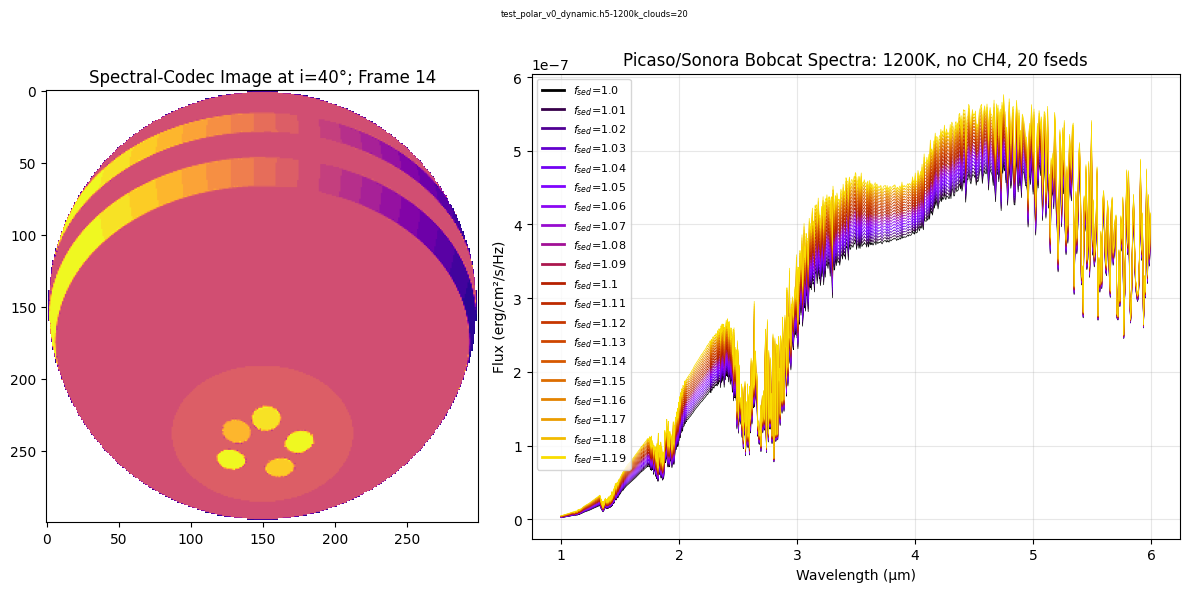

In [10]:
# ===== Plot all codecs spectra with an example image =====

# save = False
save = True

fig, axes = plt.subplots(1, 2, figsize=(12, 6), width_ratios=[1, 1.5])
if test: fig.suptitle(photrunName_td + '-' + default_specConfigName, fontsize=6)

ax = axes[0]
frame_id = 14
ax.imshow(codecs_td['40'][frame_id]['composite'], cmap='plasma')
ax.set_title(f'Spectral-Codec Image at i=40°; Frame {frame_id}')
print(codecs_td['40'][frame_id]['fractions']['fractions'])

# ===== Plot 1: All individual spectra =====
ax = axes[1]
for codec_id in range(n):  # Plot all codec
    wave_i, flux_i = codec_loaded_td.load_spectrum(codec_id)
    ax.plot(wave_i, flux_i, alpha=1, lw=0.5, color=plt.cm.gnuplot(codec_id / n))
    ax.plot([], [], lw=2, color=plt.cm.gnuplot(codec_id / n), 
            label=r'$f_{sed}$='+f'{fsed_list[codec_id][1]}')  # For legend

ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Flux (erg/cm²/s/Hz)')
ax.set_title('Picaso/Sonora Bobcat Spectra: 1200K, no CH4, 20 fseds')
ax.legend(fontsize=8)
ax.set_yscale('linear')
ax.grid(True, alpha=0.3)

plt.tight_layout()
handle = f'all_codecs_{default_specConfigName}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

plt.close(fig)

### Figure: Lightcurves for 3 different wavelength bins for i=0, 40, 80

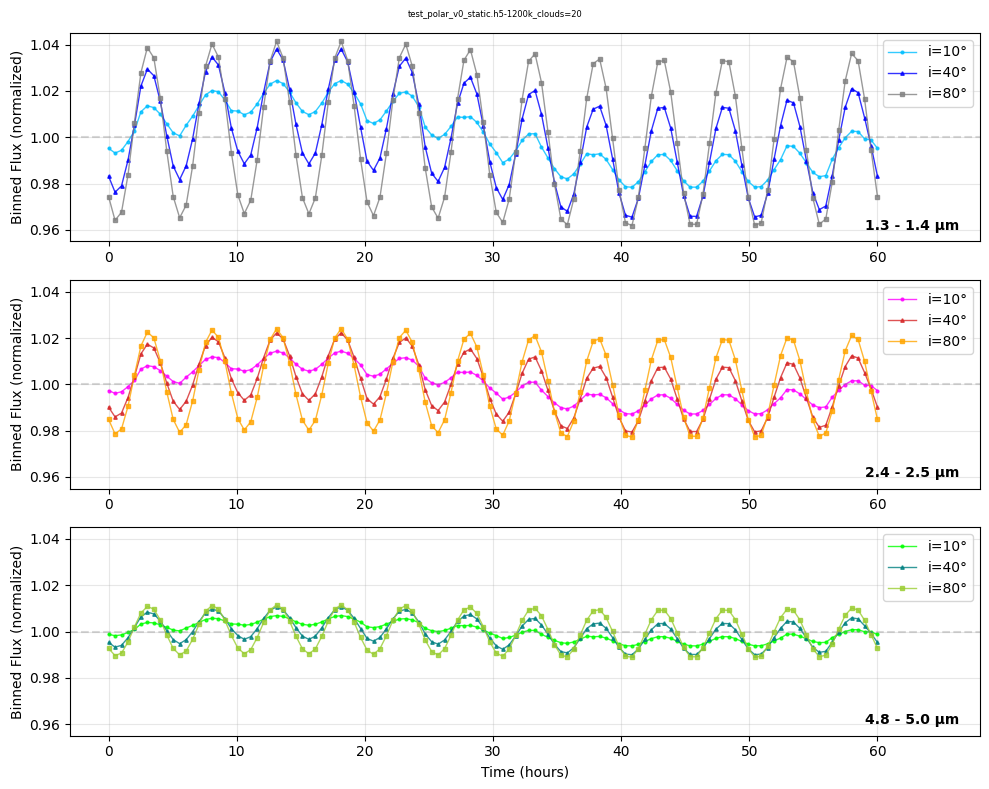

In [59]:
save = True
# save = False

normalize = True

fig, axs = plt.subplots(3, 1, figsize=(10, 8))
if test: fig.suptitle(photrunName_ts + '-' + default_specConfigName, fontsize=6)

wavebin = [ (1.3, 1.4),
            (2.4, 2.5),
            (4.8, 5.0) ]

inc_array = ['10', '40', '80']
markerstyles = ['o', '^', 's']
linestyles = ['-', '-', '-']
# map linestyles to wavemin and create a dictionary

# Define colors for different inclinations
colors = [['deepskyblue', 'blue', 'gray'],
            ['magenta', 'tab:red', 'orange'],
            ['lime', 'teal', 'yellowgreen']]

for i, (wmin, wmax) in enumerate(wavebin):
    ax = axs[i]
    for j, inclin in enumerate(inc_array):

        ### test static 
        flux_ts = []
        for keys in specs_ts[inclin]:
            frame_i, wave_i, flux_i = specs_ts[inclin][keys].values()
            # Find wavelength indices in the bin
            mask = (wave_i >= wmin) & (wave_i <= wmax)
            if np.sum(mask) > 0:
                # Calculate median flux in this bin
                median_flux = np.median(flux_i[mask])
                flux_ts.append(median_flux)
        
        # Plot normalized light curve

        # normalize flux mean to 1
        if normalize:
            flux_ts = np.array(flux_ts)
            flux_ts = (flux_ts - np.mean(flux_ts)) / np.max(flux_ts) + 1

        ax.plot(time_ts, flux_ts, 
                marker=markerstyles[j], linestyle=linestyles[j], 
                alpha=0.8, color=colors[i][j],
                linewidth=1, markersize=2+0.5*j,
                label=f'i={inclin}°')

        # Highlight specific timepoint
        # for i,xid in enumerate([26, 58, 90]):
        #     color_list = ['orange', 'green', 'purple']
        #     ax.plot(time_ts[xid], flux_ts[xid], ls='', 
        #             marker='*', markersize=12, color='k')

    if i==2: ax.set_xlabel('Time (hours)', fontsize=10)

    if normalize: ax.set_ylabel('Binned Flux (normalized)')
    else: ax.set_ylabel('Binned Flux (erg/cm²/s/Hz)')

    ax.set_xlim(-3, 68)
    if normalize: ax.set_ylim(0.955, 1.045)
    ax.legend(),
    ax.grid(True, alpha=0.3)
    ax.axhline(1, ls='--', color='gray', alpha=0.3)
    ax.text(59, 0.96, f'{wmin} - {wmax} μm', fontsize=10, weight='bold')

plt.tight_layout()
handle = f'lightcurves_bins_{default_specConfigName}.pdf'
save_path = os.path.join(plotDir, handle)
if save:
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
